Hey Ivette and Julia! As we discussed, I specifically loaded the bank-full.csv file and took the following steps for cleaning:


*   Checked for NA values (there were none to remove)
*   Converted all categorical variables to numeric
*   Defined X_bank_full and y_bank_full as features and target subsets of the bank_full dataframe

I figured for each algorithm I would let each of us do our own training and test set split, unless there's a good reason for us to use the same split. Let me know if I can answer any questions!

-Emmet

In [1]:
# From: https://archive.ics.uci.edu/dataset/222/bank+marketing
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [3]:
import pandas as pd

In [4]:
bank_full = pd.read_csv('bank-full.csv', sep = ';')
print(bank_full.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [5]:
# Count NA/NULL values in each column (code from: https://www.geeksforgeeks.org/how-to-count-the-number-of-nan-values-in-pandas/)
column_nan_count = bank_full.isna().sum()
print("NaN count per column:")
print(column_nan_count)

# Appears to be no NA/NULL values in bank_full

NaN count per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [6]:
# Identify unique labels in categorical columns
for column in list(bank_full.columns):
  unique_values= bank_full[str(column)].unique()
  print('Unique values in ' + str(column) + ':' + str(unique_values))

Unique values in age:[58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81 18 89
 84 87 92 93 88]
Unique values in job:['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
Unique values in marital:['married' 'single' 'divorced']
Unique values in education:['tertiary' 'secondary' 'unknown' 'primary']
Unique values in default:['no' 'yes']
Unique values in balance:[ 2143    29     2 ...  8205 14204 16353]
Unique values in housing:['yes' 'no']
Unique values in loan:['no' 'yes']
Unique values in contact:['unknown' 'cellular' 'telephone']
Unique values in day:[ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 28 29 30  2  3  4 11 17
 18 24 25  1 10 22 31]
Unique values in month:['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr

In [7]:
# Convert categorical variables with integers
bank_full['job'].replace(['admin.', 'blue-collar', 'entrepreneur', 'housemaid',
                          'management', 'retired', 'self-employed', 'services',
                          'student', 'technician', 'unemployed', 'unknown'],
                           [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], inplace=True)
bank_full['marital'].replace(['single', 'married', 'divorced'],[1, 2, 3], inplace=True)
bank_full['education'].replace(['tertiary', 'secondary', 'unknown', 'primary'],[3, 2, 0, 1], inplace=True)
bank_full['default'].replace(['no', 'yes'], [0, 1], inplace=True)
bank_full['housing'].replace(['yes', 'no'], [1, 0], inplace=True)
bank_full['loan'].replace(['no', 'yes'], [0, 1], inplace=True)
bank_full['contact'].replace(['unknown', 'cellular', 'telephone'], [0, 1, 2], inplace=True)
bank_full['month'].replace(['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], inplace=True)
bank_full['poutcome'].replace(['unknown', 'failure', 'other', 'success'], [2, 0, 3, 1], inplace=True)
bank_full['y'].replace(['no', 'yes'], [0, 1], inplace=True)

/var/folders/8p/zyr5g87n1_5bsq92yv67mmzc0000gn/T/ipykernel_85574/1730954829.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bank_full['job'].replace(['admin.', 'blue-collar', 'entrepreneur', 'housemaid',
/var/folders/8p/zyr5g87n1_5bsq92yv67mmzc0000gn/T/ipykernel_85574/1730954829.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('futu

In [8]:
# Verifying that variable replacement worked
print(bank_full.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    5        2          3        0     2143        1     0        0   
1   44   10        1          2        0       29        1     0        0   
2   33    3        2          2        0        2        1     1        0   
3   47    2        2          0        0     1506        1     0        0   
4   33   12        1          0        0        1        0     0        0   

   day  month  duration  campaign  pdays  previous  poutcome  y  
0    5      5       261         1     -1         0         2  0  
1    5      5       151         1     -1         0         2  0  
2    5      5        76         1     -1         0         2  0  
3    5      5        92         1     -1         0         2  0  
4    5      5       198         1     -1         0         2  0  


In [9]:
# define features and targets dataframes
X_bank_full = bank_full.drop(columns=['y'])
y_bank_full = bank_full[['y']]

print(X_bank_full.head())
print(y_bank_full.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    5        2          3        0     2143        1     0        0   
1   44   10        1          2        0       29        1     0        0   
2   33    3        2          2        0        2        1     1        0   
3   47    2        2          0        0     1506        1     0        0   
4   33   12        1          0        0        1        0     0        0   

   day  month  duration  campaign  pdays  previous  poutcome  
0    5      5       261         1     -1         0         2  
1    5      5       151         1     -1         0         2  
2    5      5        76         1     -1         0         2  
3    5      5        92         1     -1         0         2  
4    5      5       198         1     -1         0         2  
   y
0  0
1  0
2  0
3  0
4  0


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [11]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_bank_full, y_bank_full, test_size=0.2, random_state=42)

In [12]:
# Train a Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [13]:
# Make predictions
y_pred = tree_model.predict(X_test)

In [14]:
# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(accuracy)

0.8930664602454937


In [15]:
print(class_report)

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7952
           1       0.59      0.37      0.46      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.67      0.70      9043
weighted avg       0.88      0.89      0.88      9043



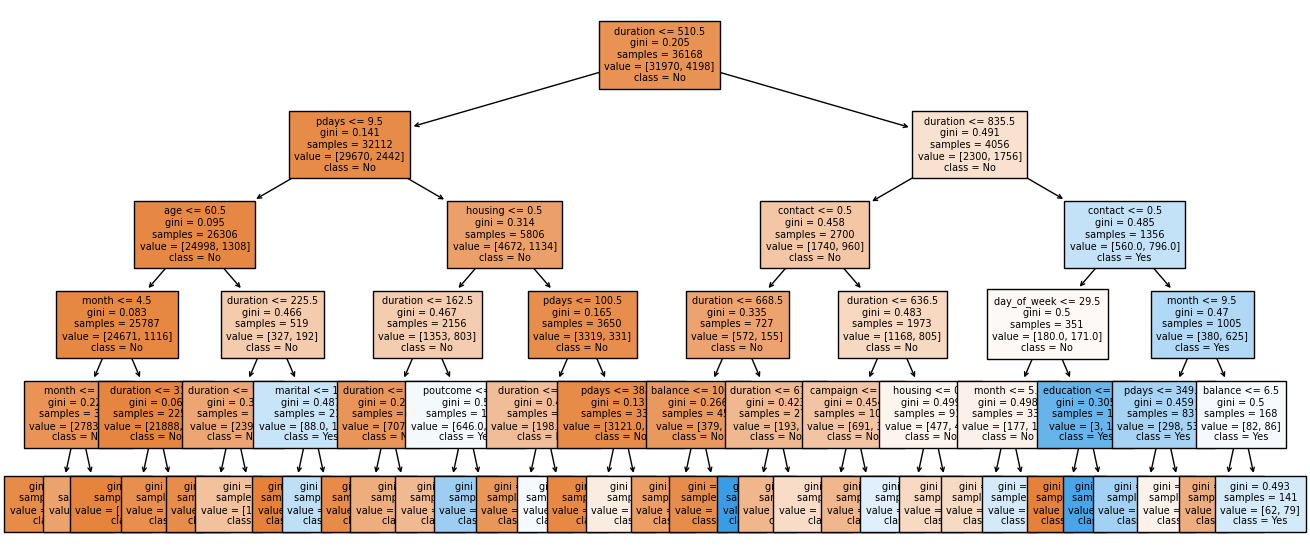

In [16]:
# Visualize the decision tree
plt.figure(figsize=(16, 7))
plot_tree(tree_model, feature_names=X.columns, class_names=["No", "Yes"], filled=True, fontsize=7)
plt.show()